==============================
PHASE 1 - STEP 1: LOAD DATASET
==============================

In [1]:
import pandas as pd

In [2]:
# Load dataset
df = pd.read_csv('../data/solar_data_large.csv')

In [3]:
# Show first 5 rows
print("First 5 rows:")
print(df.head())

First 5 rows:
   sunlight_hours  roof_area_sqft  system_size_kw  temperature_c  \
0        5.641943     1329.246469        3.323116      26.650996   
1        7.781800     1243.154639        3.107887      29.500706   
2        6.874096      961.659119        2.404148      23.633972   
3        6.313267     1189.140253        2.972851      28.534219   
4        4.541925      984.154617        2.460387      26.319659   

   monthly_generation_kwh  
0              410.834996  
1              484.833212  
2              335.039358  
3              402.728135  
4              273.893433  


In [4]:
# Dataset info
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   sunlight_hours          100000 non-null  float64
 1   roof_area_sqft          100000 non-null  float64
 2   system_size_kw          100000 non-null  float64
 3   temperature_c           100000 non-null  float64
 4   monthly_generation_kwh  100000 non-null  float64
dtypes: float64(5)
memory usage: 3.8 MB
None


In [5]:
# Statistical summary
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       sunlight_hours  roof_area_sqft  system_size_kw  temperature_c  \
count   100000.000000   100000.000000   100000.000000  100000.000000   
mean         5.996950     1202.128185        3.005320      30.010241   
std          1.170483      461.906753        1.154767       5.862191   
min          3.384974      400.007646        1.000019      16.053056   
25%          4.998218      801.148079        2.002870      25.020765   
50%          5.995572     1203.010090        3.007525      30.056940   
75%          6.998094     1600.658082        4.001645      35.005641   
max          8.626939     1999.983016        4.999958      43.201534   

       monthly_generation_kwh  
count           100000.000000  
mean               404.028282  
std                179.974082  
min                 53.833115  
25%                256.875586  
50%                386.204053  
75%                527.894282  
max               1082.669803  


In [6]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
sunlight_hours            0
roof_area_sqft            0
system_size_kw            0
temperature_c             0
monthly_generation_kwh    0
dtype: int64


In [7]:
print("\nColumns:")
print(df.columns)


Columns:
Index(['sunlight_hours', 'roof_area_sqft', 'system_size_kw', 'temperature_c',
       'monthly_generation_kwh'],
      dtype='object')


==============================
PHASE 1 - STEP 2: PREPROCESSING
==============================

In [8]:
# Check data types
print(df.dtypes)

sunlight_hours            float64
roof_area_sqft            float64
system_size_kw            float64
temperature_c             float64
monthly_generation_kwh    float64
dtype: object


==============================
PHASE 1 - STEP 3: FEATURE SETUP
==============================

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X = df[["sunlight_hours", "roof_area_sqft", "system_size_kw", "temperature_c"]]
y = df["monthly_generation_kwh"]

In [11]:
# Check shapes
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (100000, 4)
Target shape: (100000,)


In [12]:
# ---- Train/Test Split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check split
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (80000, 4)
Testing data: (20000, 4)


In [13]:
print("\nSample features:")
print(X.head())


Sample features:
   sunlight_hours  roof_area_sqft  system_size_kw  temperature_c
0        5.641943     1329.246469        3.323116      26.650996
1        7.781800     1243.154639        3.107887      29.500706
2        6.874096      961.659119        2.404148      23.633972
3        6.313267     1189.140253        2.972851      28.534219
4        4.541925      984.154617        2.460387      26.319659


==============================
PHASE 1 - STEP 4: MODEL TRAINING
==============================

In [14]:
from sklearn.ensemble import RandomForestRegressor

In [23]:
# Initialize model
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [24]:
# Train model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [25]:
# Make predictions on test data
y_pred = model.predict(X_test)

In [26]:
# Show sample predictions
print("\nSample Predictions:")
print(y_pred[:10])


Sample Predictions:
[325.15412287 123.60043769 688.90331164 397.93932095 168.36412071
 524.95107963 562.05405443 599.75381057 387.21402349 321.90537476]


In [27]:
import numpy as np

print("\nPrediction range:")
print("Min:", np.min(y_pred))
print("Max:", np.max(y_pred))


Prediction range:
Min: 89.96350259407895
Max: 927.473523731831


==============================
PHASE 1 - STEP 5: EVALUATION
==============================

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [29]:
# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [30]:
# Print results
print("Model Evaluation:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R2   : {r2:.4f}")

Model Evaluation:
MAE  : 30.34
RMSE : 42.27
R2   : 0.9450


==============================
PHASE 1 - STEP 6: FEATURE IMPORTANCE
==============================

In [31]:
import pandas as pd

In [32]:
# Get feature importance
importances = model.feature_importances_

In [33]:
# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

In [34]:
# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

In [35]:
# Display
print(feature_importance_df)

          Feature  Importance
1  roof_area_sqft    0.398149
2  system_size_kw    0.365334
0  sunlight_hours    0.221387
3   temperature_c    0.015130


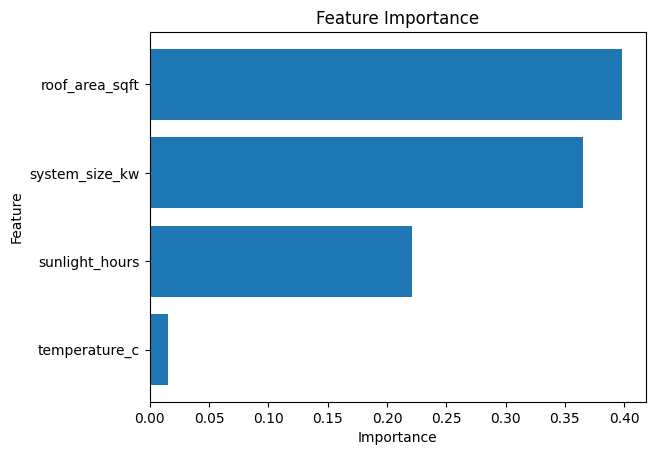

In [36]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.show()